<a href="https://colab.research.google.com/github/souhaylelhammadi/analytique-des-donn-es-et-informatique-d-cisionnelle/blob/main/TP2_Impl%C3%A9mentation_d%E2%80%99un_neurone_artificiel_en_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

#Fonction d'activation : sigmoide
def sigmoid(z):
  return 1/(1+np.exp(-z))

class Neurone :
  def __init__(self,n_inputs):
    #initialiser poids et biais
    self.w=np.random.randn(n_inputs)
    self.b=np.random.randn()
  def forward(self,x):
    #produit scalaire + biais
    z=np.dot(self.w,x)+self.b
    return sigmoid(z)

#creer un neurone avec 2 entreees
neurone=Neurone(2)
#Exemple d'entree
x = np.array([1, 0]) # comme un signal binaire
#sortie
y=neurone.forward(x)
print('sortie du neurone :',y)

sortie du neurone : 0.5605011575901505


In [ ]:
# Dataset OR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([0,1,1,1])
# Prédictions du neurone avant apprentissage
for i in range(len(X)):
  print(f"Entrée : {X[i]}, Sortie : {neurone.forward(X[i])}")

Entrée : [0 0], Sortie : 0.6705778709098077
Entrée : [0 1], Sortie : 0.7448569604970786
Entrée : [1 0], Sortie : 0.5605011575901505
Entrée : [1 1], Sortie : 0.6465170364128374


In [ ]:
#Fonction perte (erreur quadratique )
def loss(y_true,y_pred):
  return 0.5*(y_true-y_pred)**2
#derivee de la sigmoide
def sigmoid_derivative(z):
  return sigmoid(z)*(1-sigmoid(z))
#Entrainement du neurone
def train (neurone , X ,Y,epochs=1000,lr=0.1):
  for epoch in range (epochs):
    total_loss=0
    for x,y_true in zip(X,Y):
      #forward
      z = np.dot(neurone.w, x) + neurone.b
      y_pred = sigmoid(z)
      # Calcul de l'erreur
      error = y_true - y_pred
      total_loss += loss(y_true, y_pred)
      # Gradients
      dL_dy = -(y_true - y_pred)
      dy_dz = sigmoid_derivative(z)
      dz_dw = x
      dz_db = 1
      # Mise à jour poids et biais
      neurone.w -= lr * dL_dy * dy_dz * dz_dw
      neurone.b -= lr * dL_dy * dy_dz * dz_db
  if epoch % 100 == 0:
    print(f"Epoch {epoch}, Loss : {total_loss:.4f}")

In [ ]:
# Nouveau neurone
neurone = Neurone(2)
# Entraînement
train(neurone, X, Y, epochs=1000, lr=0.1)
# Résultats
print("\nPrédictions après apprentissage :")
for i in range(len(X)):
  print(f"Entrée : {X[i]}, Sortie : {neurone.forward(X[i]):.4f}")


Prédictions après apprentissage :
Entrée : [0 0], Sortie : 0.2056
Entrée : [0 1], Sortie : 0.8784
Entrée : [1 0], Sortie : 0.8772
Entrée : [1 1], Sortie : 0.9950


# Exercice 1 : Jouer avec le neurone (comprendre l’effet des poids et du biais sur la sortie)

1. Création d’un neurone avec 2 entrées

In [ ]:
import numpy as np

#Fonction d'activation : sigmoide
def sigmoid(z):
  return 1/(1+np.exp(-z))

class Neurone :
  def __init__(self,n_inputs):
    #initialiser poids et biais
    self.w=np.random.randn(n_inputs)
    self.b=np.random.randn()
  def forward(self,x):
    #produit scalaire + biais
    z=np.dot(self.w,x)+self.b
    return sigmoid(z)

#creer un neurone avec 2 entreees
neurone=Neurone(2)


2. Modification manuelle des poids et du biais

On change manuellement les valeurs :

In [ ]:
neurone.w = np.array([5, 5])
neurone.b = -2

Signification mathématique :

Le neurone calcule :

𝑧=
𝑤
1
𝑥
1
+
𝑤
2
𝑥
2
+
𝑏

y=σ(z)

Ici :

𝑧=
5
𝑥
1
+
5
𝑥
2
−
2


3. Teste-le sur les 4 entrées de la table OR et observe comment la sortie change.

In [ ]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])

for x in X:
    print(f"Entrée : {x}, Sortie : {neurone.forward(x):.4f}")

Entrée : [0 0], Sortie : 0.1192
Entrée : [0 1], Sortie : 0.9526
Entrée : [1 0], Sortie : 0.9526
Entrée : [1 1], Sortie : 0.9997


# **Interprétation**

# Effet des poids (w)

Plus les poids sont grands et positifs, plus la sortie tend vers
1.Si les poids sont négatifs → la sortie tend vers 0.

Les poids contrôlent l’importance de chaque entrée.

# Effet du biais (b)

Le biais décale la frontière de décision.

Si b est très négatif → plus difficile d’obtenir 1.

Si b est positif → plus facile d’obtenir 1.

# **Exercice 2 : Ajouter l’apprentissage**

In [ ]:
#Fonction sigmoide
def sigmoid(z):
  return 1/(1+np.exp(-z))
def sigmoid_derivative(z):
  return sigmoid(z)*(1-sigmoid(z))

def mse (Y_true,Y_pred):
  return np.mean((Y_true -Y_pred)**2)
class Neurone :
  def __init__(self,n_inputs):
    self.w=np.random.randn(n_inputs)
    self.b=np.random.randn()
  def forward(self,x):
    z=np.dot(self.w,x)+self.b
    return sigmoid(z)
  def train(self,X,Y,epochs=1000,lr=0.1):
    for epoch in range(epochs):
      total_loss=0
      for x,y_true in zip(X,Y):

        #Forward
        z=np.dot(self.w,x)+self.b
        y_pred=sigmoid(z)

        #error
        error = y_pred - y_true
        total_loss += 0.5 * error**2

        #Gradients
        dL_dy=error
        dy_dz=sigmoid_derivative(z)
        # Mise à jour
        self.w -= lr * dL_dy * dy_dz * x
        self.b -= lr * dL_dy * dy_dz

      # Affichage chaque 100 itérations
      if epoch % 100 == 0:
            print(f"Epoch {epoch} | MSE : {total_loss/len(X):.4f}")


2. Application sur la logique OR

In [ ]:
# Dataset OR
X_or = np.array([[0,0],[0,1],[1,0],[1,1]])
Y_or = np.array([0,1,1,1])

print("=== Apprentissage OR ===")
neurone_or = Neurone(2)
neurone_or.train(X_or, Y_or, epochs=1000, lr=0.1)

print("\nPrédictions OR :")
for x in X_or:
    print(x, "->", neurone_or.forward(x))

=== Apprentissage OR ===
Epoch 0 | MSE : 0.1156
Epoch 100 | MSE : 0.0719
Epoch 200 | MSE : 0.0482
Epoch 300 | MSE : 0.0335
Epoch 400 | MSE : 0.0251
Epoch 500 | MSE : 0.0199
Epoch 600 | MSE : 0.0164
Epoch 700 | MSE : 0.0139
Epoch 800 | MSE : 0.0120
Epoch 900 | MSE : 0.0105

Prédictions OR :
[0 0] -> 0.20870070830998239
[0 1] -> 0.8711972155479871
[1 0] -> 0.8814397408448935
[1 1] -> 0.994782450874468


3. Application sur la logique AND

In [ ]:
# Dataset AND
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
Y_and = np.array([0,0,0,1])

print("\n=== Apprentissage AND ===")
neurone_and = Neurone(2)
neurone_and.train(X_and, Y_and, epochs=1000, lr=0.1)

print("\nPrédictions AND :")
for x in X_and:
    print(x, "->", neurone_and.forward(x))


=== Apprentissage AND ===
Epoch 0 | MSE : 0.1446
Epoch 100 | MSE : 0.0946
Epoch 200 | MSE : 0.0646
Epoch 300 | MSE : 0.0488
Epoch 400 | MSE : 0.0393
Epoch 500 | MSE : 0.0328
Epoch 600 | MSE : 0.0281
Epoch 700 | MSE : 0.0244
Epoch 800 | MSE : 0.0215
Epoch 900 | MSE : 0.0192

Prédictions AND :
[0 0] -> 0.019100800075999454
[0 1] -> 0.1986998411849006
[1 0] -> 0.1990535443408923
[1 1] -> 0.7598904462106635


Un neurone simple = modèle linéaire :

𝑧=
𝑤
1
𝑥
1
+
𝑤
2
𝑥
2
+
𝑏


OR et AND sont séparables par une droite → donc apprentissage possible.

# Exercice 3 : Visualiser la frontière de décision(Objectif : voir comment un neurone sépare l’espace en deux régions.)

1. Trace un plan (x1, x2) ∈ [0,1].

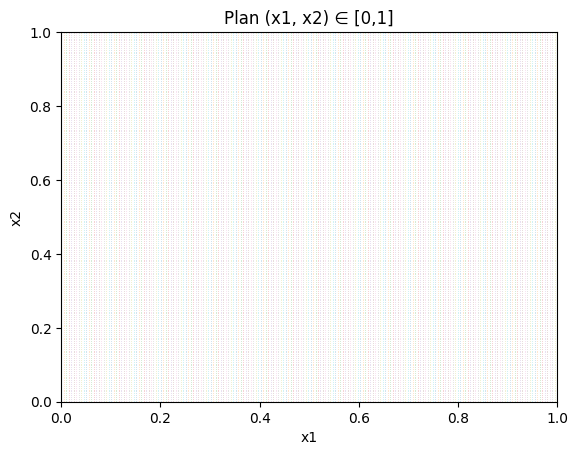

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Création du plan
xx, yy = np.meshgrid(np.linspace(0,1,200),
                     np.linspace(0,1,200))

plt.figure()
plt.plot(xx, yy, ',', alpha=0.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Plan (x1, x2) ∈ [0,1]")
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

2. Colore les points selon la sortie du neurone après apprentissage.

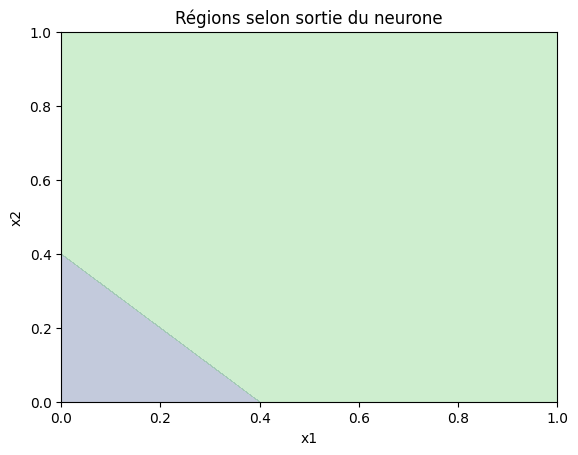

In [ ]:

# Grille
xx, yy = np.meshgrid(np.linspace(0,1,200),
                     np.linspace(0,1,200))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([neurone.forward(p) for p in grid])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z>0.5, alpha=0.3)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Régions selon sortie du neurone")
plt.show()

3. Ajoute la vraie table de vérité (points rouges/verts).

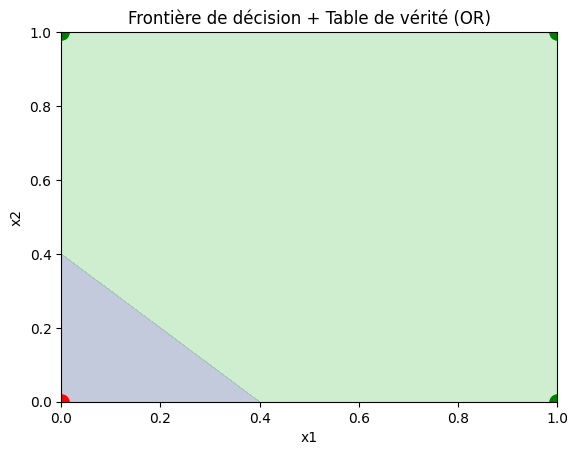

In [ ]:
plt.figure()

# Région de décision
plt.contourf(xx, yy, Z>0.5, alpha=0.3)

# Points réels
for i in range(len(X)):
    if Y[i] == 1:
        plt.scatter(X[i,0], X[i,1], color="green", s=120)
    else:
        plt.scatter(X[i,0], X[i,1], color="red", s=120)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Frontière de décision + Table de vérité (OR)")
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

# Exercice 4 : Tester différentes fonctions logiques (Objectif : montrer qu’un neurone unique peut modéliser des fonctions linéaires séparables.)
• Apprends un neurone pour :

o OR

o AND

o NAND

• Compare les poids finaux et la précision.

In [ ]:
import numpy as np


# Fonctions mathématiques

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

def accuracy(Y_true, Y_pred):
    Y_pred_binary = (Y_pred >= 0.5).astype(int)
    return np.mean(Y_true == Y_pred_binary)


# Classe Neurone


class Neurone:
    def __init__(self, n_inputs):
        self.w = np.random.randn(n_inputs)
        self.b = np.random.randn()

    def forward(self, x):
        return sigmoid(np.dot(self.w, x) + self.b)

    def train(self, X, Y, epochs=1000, lr=0.1):
        for epoch in range(epochs):
            for x, y_true in zip(X, Y):
                z = np.dot(self.w, x) + self.b
                y_pred = sigmoid(z)

                error = y_pred - y_true
                grad = error * sigmoid_derivative(z)

                self.w -= lr * grad * x
                self.b -= lr * grad


# Dataset de base

X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

# Fonctions logiques
Y_or   = np.array([0,1,1,1])
Y_and  = np.array([0,0,0,1])
Y_nand = np.array([1,1,1,0])

# Fonction test


def tester_fonction(Y, nom):
    neurone = Neurone(2)
    neurone.train(X, Y, epochs=1000, lr=0.1)

    predictions = np.array([neurone.forward(x) for x in X])
    acc = accuracy(Y, predictions)

    print(f"\n===== {nom} =====")
    print("Poids finaux :", neurone.w)
    print("Biais final :", neurone.b)
    print("Prédictions :", (predictions >= 0.5).astype(int))
    print("Précision :", acc)


# Tests


tester_fonction(Y_or, "OR")
tester_fonction(Y_and, "AND")
tester_fonction(Y_nand, "NAND")


===== OR =====
Poids finaux : [3.16953829 3.18330506]
Biais final : -1.2707780807185036
Prédictions : [0 1 1 1]
Précision : 1.0

===== AND =====
Poids finaux : [2.43153059 2.42853949]
Biais final : -3.768558367539152
Prédictions : [0 0 0 1]
Précision : 1.0

===== NAND =====
Poids finaux : [-2.36335478 -2.37011961]
Biais final : 3.675345246446705
Prédictions : [1 1 1 0]
Précision : 1.0


# Exercice 5 : Le cas du XOR (Objectif : comprendre la limite d’un perceptron simple et pourquoi on a besoin de réseaux plus profonds.)

In [ ]:

# Fonctions

def sigmoid(z):
    return 1/(1+np.exp(-z))

def sigmoid_derivative(z):
    return sigmoid(z)*(1-sigmoid(z))

def accuracy(Y_true, Y_pred):
    Y_pred_binary = (Y_pred >= 0.5).astype(int)
    return np.mean(Y_true == Y_pred_binary)


# Classe Neurone



class Neurone:
    def __init__(self, n_inputs):
        self.w = np.random.randn(n_inputs)
        self.b = np.random.randn()

    def forward(self, x):
        return sigmoid(np.dot(self.w, x) + self.b)

    def train(self, X, Y, epochs=2000, lr=0.1):
        for _ in range(epochs):
            for x, y in zip(X,Y):
                z = np.dot(self.w,x)+self.b
                y_pred = sigmoid(z)
                error = y_pred - y
                grad = error * sigmoid_derivative(z)
                self.w -= lr * grad * x
                self.b -= lr * grad

# XOR Dataset

X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y_xor = np.array([0,1,1,0])

# Entraînement
neurone = Neurone(2)
neurone.train(X, Y_xor)

# Test
predictions = np.array([neurone.forward(x) for x in X])
print("Prédictions :", (predictions>=0.5).astype(int))
print("Précision :", accuracy(Y_xor, predictions))

Prédictions : [1 0 0 0]
Précision : 0.25


2. Observation

La précision sera autour de :

Précision ≈ 0.5

Le neurone échoue.

Il ne peut pas séparer correctement les classes.

Pourquoi un neurone seul ne peut pas apprendre XOR ?

Un neurone simple crée une séparation :

𝑤
1
𝑥
1
+
𝑤
2
𝑥
2
+
𝑏


C’est une droite.

Mais XOR ressemble à ça :

(0,0) → 0

(0,1) → 1

(1,0) → 1

(1,1) → 0

Les classes sont croisées en diagonale.

Aucune droite ne peut séparer :

les deux "1"

des deux "0"

XOR n’est pas linéairement séparable.

4. Solution : Petit réseau multicouche (MLP)

2 entrées
   ↓
2 neurones cachés
   ↓
1 neurone de sortie

In [ ]:

def sigmoid(z):
    return 1/(1+np.exp(-z))

def sigmoid_derivative(z):
    return z*(1-z)

class MLP:
    def __init__(self):
        # 2 -> 2
        self.W1 = np.random.randn(2,2)
        self.b1 = np.random.randn(2)

        # 2 -> 1
        self.W2 = np.random.randn(2,1)
        self.b2 = np.random.randn(1)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2

    def train(self, X, Y, epochs=5000, lr=0.1):
        Y = Y.reshape(-1,1)

        for _ in range(epochs):

            # Forward
            output = self.forward(X)

            # Erreur sortie
            error2 = Y - output
            d2 = error2 * sigmoid_derivative(output)

            # Erreur couche cachée
            error1 = d2.dot(self.W2.T)
            d1 = error1 * sigmoid_derivative(self.a1)

            # Mise à jour
            self.W2 += self.a1.T.dot(d2) * lr
            self.b2 += np.sum(d2, axis=0) * lr

            self.W1 += X.T.dot(d1) * lr
            self.b1 += np.sum(d1, axis=0) * lr

# XOR


X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([0,1,1,0])

mlp = MLP()
mlp.train(X,Y)

pred = mlp.forward(X)
print("Prédictions :", (pred>=0.5).astype(int).flatten())

Prédictions : [0 1 1 0]


Résultat

Tu dois obtenir :

[0 1 1 0]

**XOR est appris correctement.**

 Conclusion Finale

Modèle	       ->     XOR

Neurone simple	       ->  Impossible

MLP (2-2-1)	          ->           Réussi

# Exercice 6 : Expérimenter avec le taux d’apprentissage (Objectif : comprendre l’effet du learning rate.)

1 Code de base (Neurone + Dataset OR)

In [ ]:

# Fonctions


def sigmoid(z):
    return 1/(1+np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s*(1-s)

# Classe Neurone

class Neurone:
    def __init__(self, n_inputs):
        self.w = np.random.randn(n_inputs)
        self.b = np.random.randn()

    def forward(self, x):
        return sigmoid(np.dot(self.w,x)+self.b)

    def train(self, X, Y, epochs=200, lr=0.1):
        losses = []
        for epoch in range(epochs):
            total_loss = 0
            for x, y in zip(X,Y):
                z = np.dot(self.w,x)+self.b
                y_pred = sigmoid(z)

                error = y_pred - y
                total_loss += 0.5 * error**2

                grad = error * sigmoid_derivative(z)

                self.w -= lr * grad * x
                self.b -= lr * grad

            losses.append(total_loss/len(X))
        return losses

# Dataset OR


X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

Y = np.array([0,1,1,1])

2 Code pour lr = 0.01

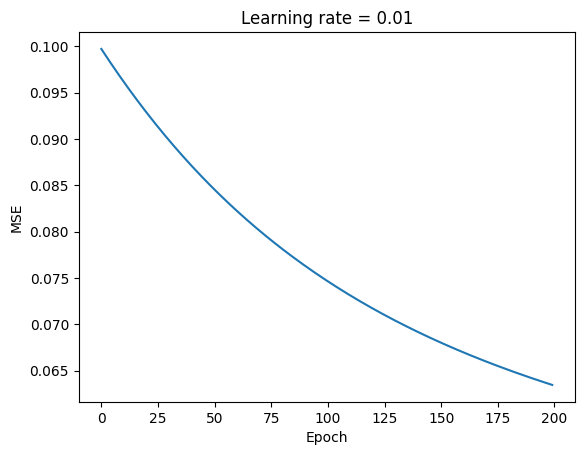

In [ ]:
neurone1 = Neurone(2)
losses1 = neurone1.train(X, Y, epochs=200, lr=0.01)

plt.figure()
plt.plot(losses1)
plt.title("Learning rate = 0.01")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

3  Code pour lr = 0.1

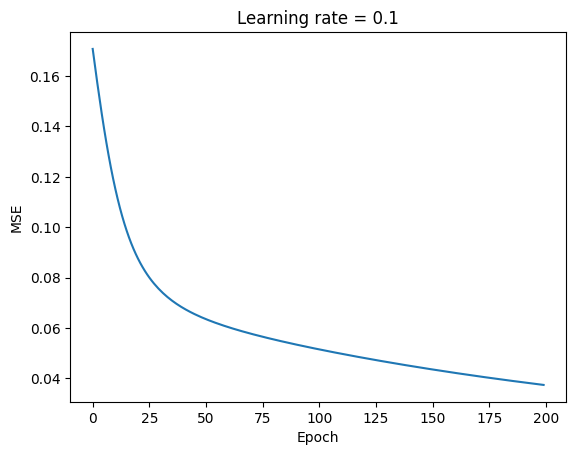

In [ ]:
neurone2 = Neurone(2)
losses2 = neurone2.train(X, Y, epochs=200, lr=0.1)

plt.figure()
plt.plot(losses2)
plt.title("Learning rate = 0.1")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

4  Code pour lr = 1.0

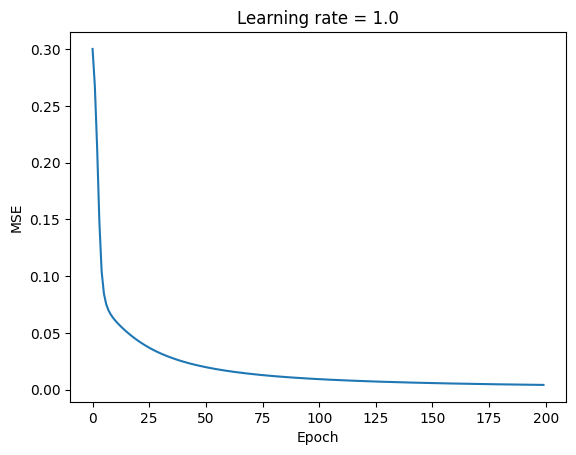

In [ ]:
neurone3 = Neurone(2)
losses3 = neurone3.train(X, Y, epochs=200, lr=1.0)

plt.figure()
plt.plot(losses3)
plt.title("Learning rate = 1.0")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

# Conclusion



| Learning Rate | Vitesse     | Stabilité             |
| ------------- | ----------- | --------------------- |
| 0.01          | Lente       | Très stable           |
| 0.1           | Bonne       | Stable                |
| 1.0           | Très rapide | Peut devenir instable |
